In [1]:
#from google.colab import files
#uploaded = files.upload()

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('diabetes.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


The Diabetes dataset contains only 768 rows, 8 independent features and 1 dependent feature. All the input features are numerical and continuous in nature.

In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
df.dtypes


Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

**Data Preprocessing :- Wrong Null and Zero Values**

In [7]:
df.isnull().sum() # Checking for Null values


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
df.duplicated().sum() # Checking for duplicate values

np.int64(0)

 No missing values or duplicate records are present.

In [9]:
df.isin([0]).sum() #Validaiting for zero values recorded for different independent parameters

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

 The above  we can see that **Glucose, BloodPressure, SkinThickness, Insulin and the BMI** have min values of 0 which are not real clinical values. This is logically incorrect as these values cannot be 0. This is called "missing data". We can either drop the 0-valued rows or we can replace them with the mean or median value of that respective feature.  
 A value of 0 for Pregnancies can be a real value.

In [10]:
for col in df.columns:
  if col in ['Glucose','BloodPressure','SkinThickness', 'Insulin', 'BMI']:
     print(f"Percentage of missing data for {col} is  {round(df[col].isin([0]).sum()/df[col].count()*100,2)}")

Percentage of missing data for Glucose is  0.65
Percentage of missing data for BloodPressure is  4.56
Percentage of missing data for SkinThickness is  29.56
Percentage of missing data for Insulin is  48.7
Percentage of missing data for BMI is  1.43


 Correct/clean the Zero Values in the data columns Glucose, BloodPressure, SkinThickness, Insulin and the BMI. As, real time values cannot be zero.


In [11]:
df.loc[df['Glucose'].isin([0])]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
75,1,0,48,20,0,24.7,0.140,22,0
182,1,0,74,20,23,27.7,0.299,21,0
342,1,0,68,35,0,32.0,0.389,22,0
349,5,0,80,32,0,41.0,0.346,37,1
502,6,0,68,41,0,39.0,0.727,41,1


In [12]:
df.loc[df['BMI'].isin([0]) & df['Insulin'].isin([0]) & df['BloodPressure'].isin([0]) & df['SkinThickness'].isin([0])]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
49,7,105,0,0,0,0.0,0.305,24,0
60,2,84,0,0,0,0.0,0.304,21,0
81,2,74,0,0,0,0.0,0.102,22,0
426,0,94,0,0,0,0.0,0.256,25,0
494,3,80,0,0,0,0.0,0.174,22,0
522,6,114,0,0,0,0.0,0.189,26,0
706,10,115,0,0,0,0.0,0.261,30,1


We will remove the 7 rows where values are 0 for BloodPressure,SkinThickness,Insulin and BMI as well.

In [13]:
df.loc[df['BMI'].isin([0]) & df['Insulin'].isin([0]) & df['BloodPressure'].isin([0]) & df['SkinThickness'].isin([0])].index

Index([49, 60, 81, 426, 494, 522, 706], dtype='int64')

In [14]:
df.drop(index=df.loc[df['BMI'].isin([0]) & df['Insulin'].isin([0]) & df['BloodPressure'].isin([0]) & df['SkinThickness'].isin([0])].index, inplace=True)

In [15]:
df_diabetes = df.copy()

Replacing all the zero values with the mean of Glucose, BloodPressure,SkinThickness, Insulin and the BMI.

In [16]:
df_diabetes['Glucose'] = df['Glucose'].replace(0,df['Glucose'].mean())
df_diabetes['BloodPressure'] = df['BloodPressure'].replace(0,df['BloodPressure'].mean())
df_diabetes['SkinThickness'] = df['SkinThickness'].replace(0,df['SkinThickness'].mean())
df_diabetes['Insulin'] = df['Insulin'].replace(0,df['Insulin'].mean())
df_diabetes['BMI'] = df['BMI'].replace(0,df['BMI'].mean())

In [17]:
df_diabetes.isin([0]).sum()

Pregnancies                 110
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     494
dtype: int64

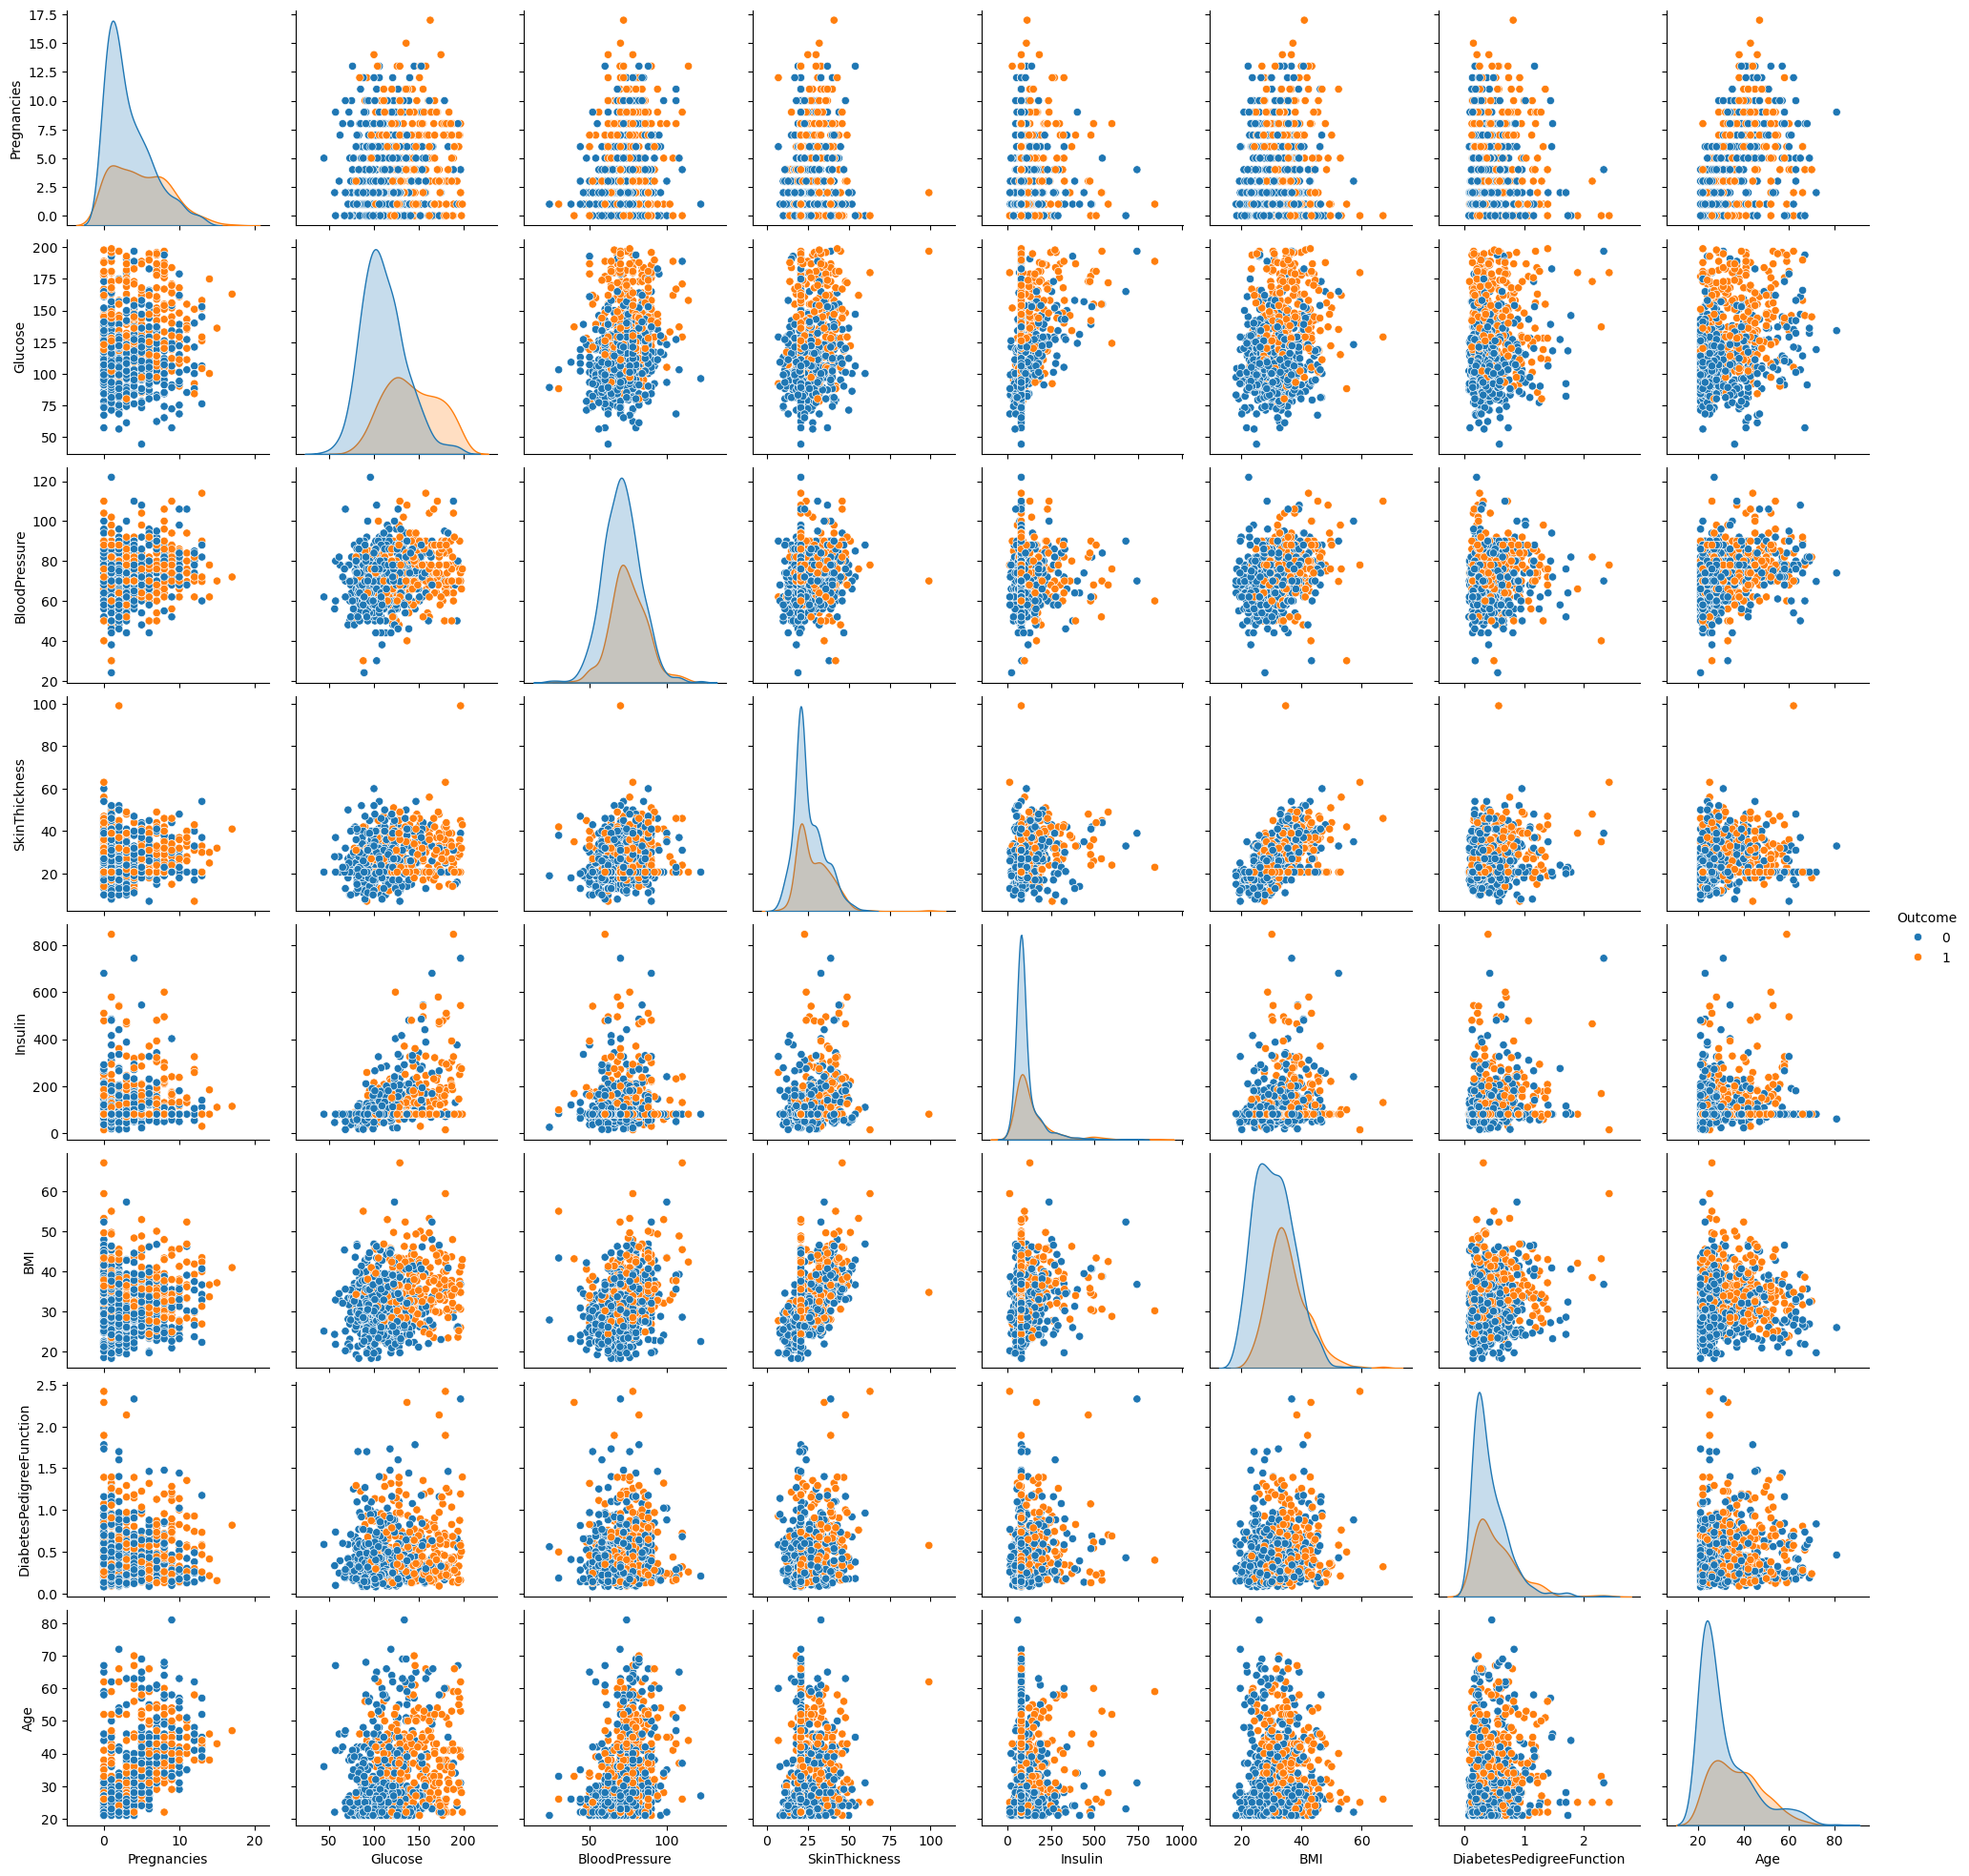

In [18]:
sns.pairplot(df_diabetes, diag_kind='kde', hue='Outcome');

<Axes: xlabel='Outcome', ylabel='count'>

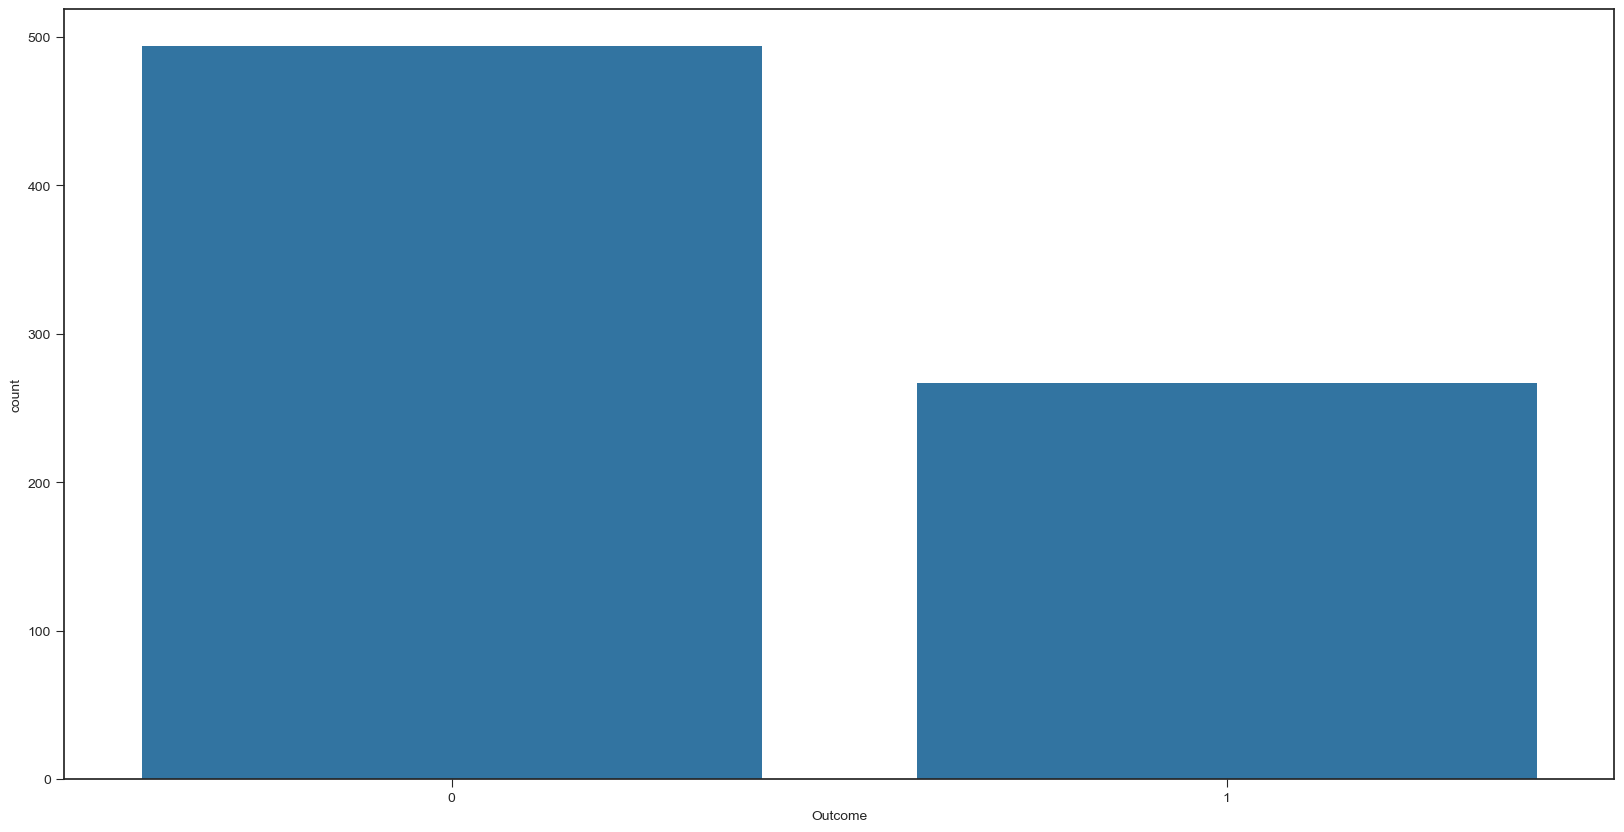

In [19]:
fig = plt.figure(figsize=(20,10))
plt.style.use('seaborn-v0_8-ticks')
sns.countplot(x="Outcome", data=df_diabetes)

In [20]:
round((df_diabetes['Outcome'].value_counts()/df_diabetes['Outcome'].count())*100,2)

Outcome
0    64.91
1    35.09
Name: count, dtype: float64

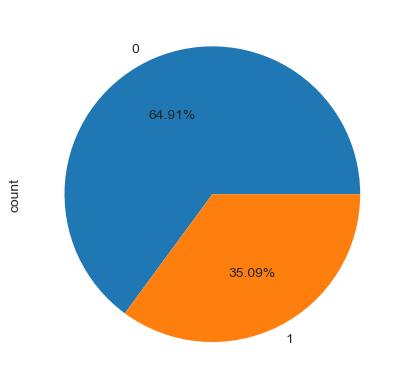

<Figure size 1000x600 with 0 Axes>

In [21]:
df_diabetes['Outcome'].value_counts().plot.pie(autopct='%1.2f%%')
plt.figure(figsize=(10,6))
plt.show()

We observe from the above plot that:

64.91% patients in the dataset do not have diabetes - Class 0.
35.09% patients in the dataset has diabetes - Class 1.
Hence, the data is imbalanced.

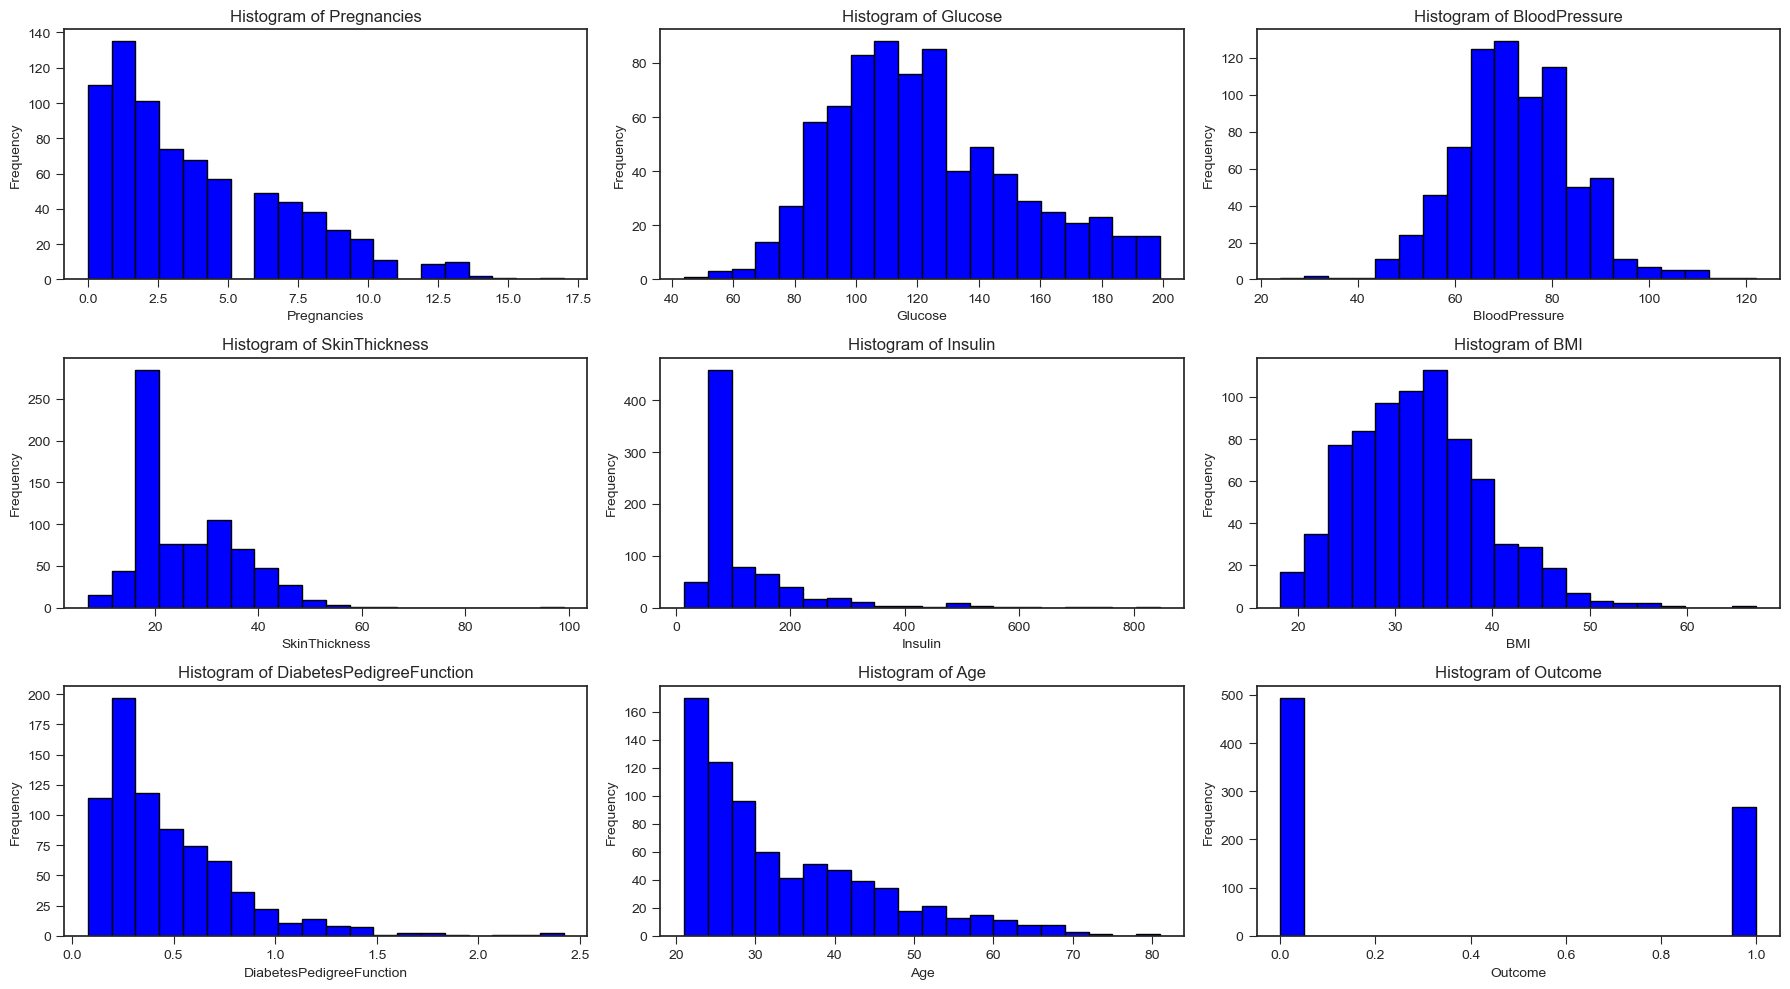

In [22]:
#All columns are Continuous Values

fig, axes = plt.subplots(3,3, figsize=(18, 10))

# Flatten the 2D axis array to make it easier to iterate
axes = axes.flatten()

# Loop through each numeric column and plot its histogram
for i, col in enumerate(df_diabetes):
    axes[i].hist(df_diabetes[col], bins=20, color='blue', edgecolor='black')
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

In [23]:
for col in df_diabetes.columns:
    print(f'{col} - skew value : {df_diabetes[col].skew()}')

Pregnancies - skew value : 0.9058302085868363
Glucose - skew value : 0.5262430258945912
BloodPressure - skew value : 0.16018587445626287
SkinThickness - skew value : 1.2154069534418483
Insulin - skew value : 3.280105948748353
BMI - skew value : 0.5959183319844088
DiabetesPedigreeFunction - skew value : 1.911071836224477
Age - skew value : 1.118613249263374
Outcome - skew value : 0.6262735940661137


In [24]:
for col in df_diabetes.columns:
    print(f'{col} - Mean  : {df_diabetes[col].mean()}')
    print(f'{col} - Median  : {df_diabetes[col].median()}')
    print(f'{col} - Mode  : {df_diabetes[col].mode()}')
    print(f'\n')

Pregnancies - Mean  : 3.840998685939553
Pregnancies - Median  : 3.0
Pregnancies - Mode  : 0    1
Name: Pregnancies, dtype: int64


Glucose - Mean  : 121.92727599240918
Glucose - Median  : 118.0
Glucose - Mode  : 0     99.0
1    100.0
Name: Glucose, dtype: float64


BloodPressure - Mean  : 72.30716378787852
BloodPressure - Median  : 72.0
BloodPressure - Mode  : 0    70.0
Name: BloodPressure, dtype: float64


SkinThickness - Mean  : 26.716924442387683
SkinThickness - Median  : 23.0
SkinThickness - Mode  : 0    20.725361
Name: SkinThickness, dtype: float64


Insulin - Mean  : 119.37161318619079
Insulin - Median  : 80.5335085413929
Insulin - Mode  : 0    80.533509
Name: Insulin, dtype: float64


BMI - Mean  : 32.45656693506193
BMI - Median  : 32.2868593955322
BMI - Mode  : 0    32.0
Name: BMI, dtype: float64


DiabetesPedigreeFunction - Mean  : 0.4741261498028909
DiabetesPedigreeFunction - Median  : 0.378
DiabetesPedigreeFunction - Mode  : 0    0.254
1    0.258
Name: DiabetesPedigreeFuncti

The columns Glucose,Blood Pressure and BMI are almost symmetrically distributed. Rest of the values are slightly right skewed.

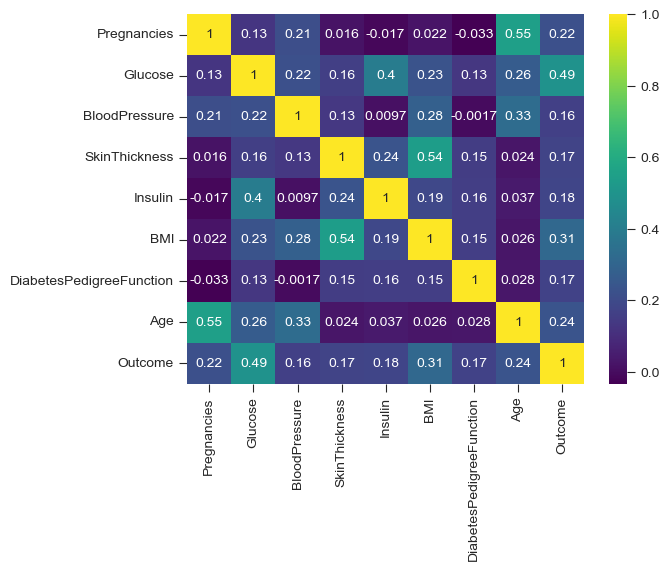

In [25]:
sns.heatmap(df_diabetes.corr(), annot=True,cmap="viridis");

In [26]:
df_diabetes.corr()["Outcome"].sort_values(ascending=False)


Outcome                     1.000000
Glucose                     0.491583
BMI                         0.312991
Age                         0.235470
Pregnancies                 0.219453
Insulin                     0.178720
SkinThickness               0.174560
DiabetesPedigreeFunction    0.171662
BloodPressure               0.163361
Name: Outcome, dtype: float64

The above **correlation matrix/heat map** shows that the outcome shows moderately positive correlation with the Glucose(0.49) and BMI(0.31).

The input columns Age has moderate Correlations with Pregnancies(0.55) and Blood Pressure(0.33).


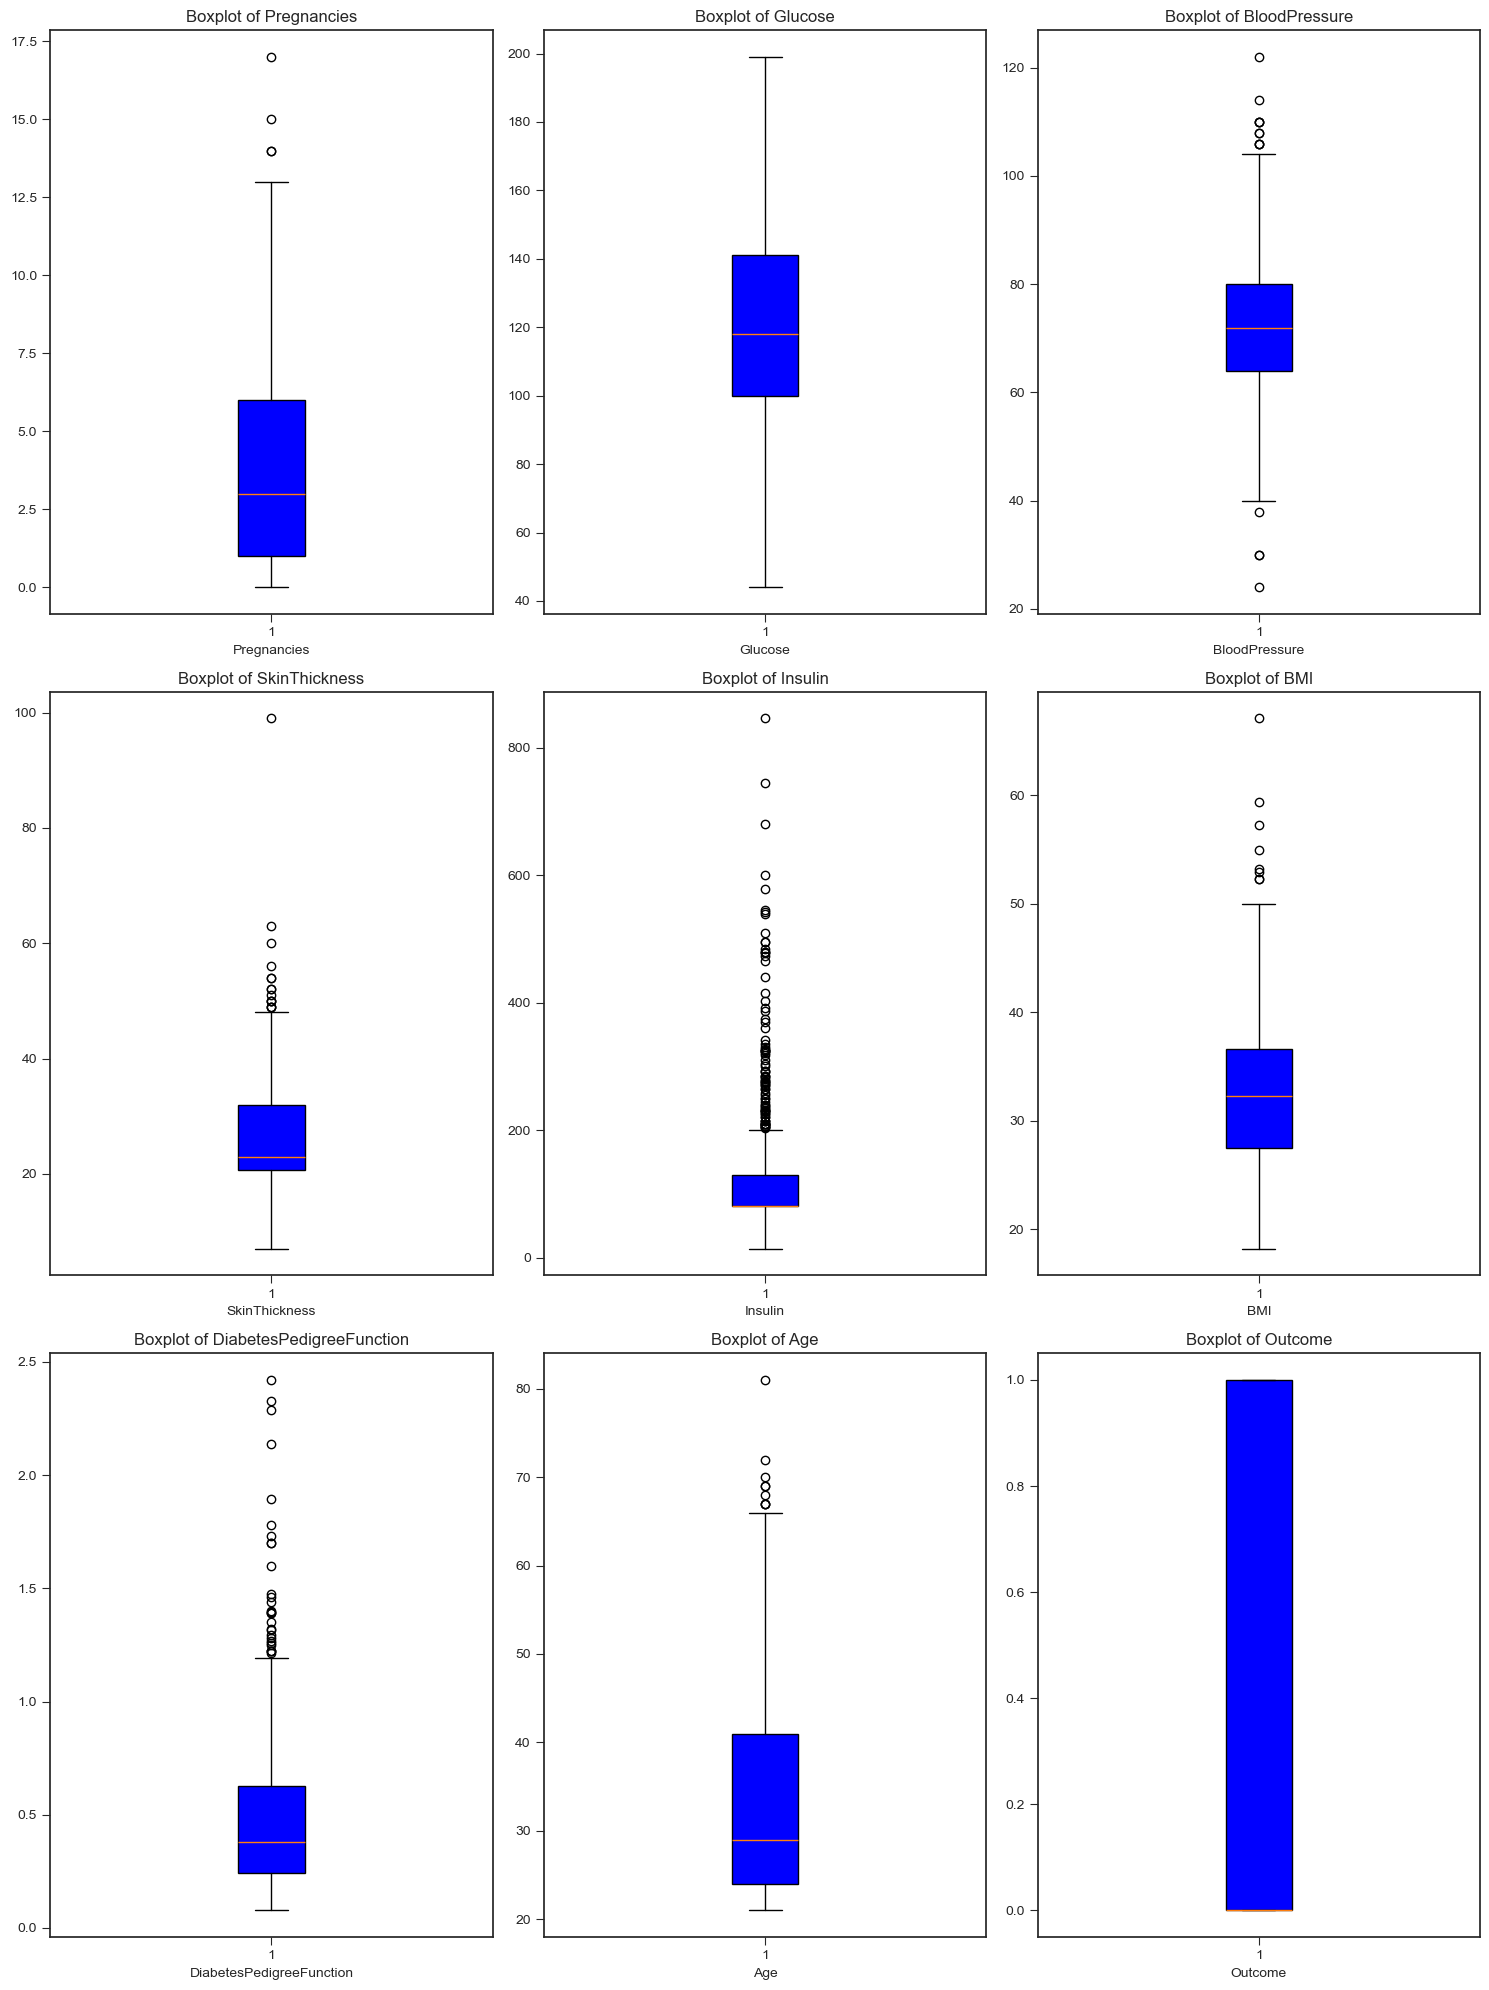

In [27]:
fig, axes = plt.subplots(3,3, figsize=(15, 20))
axes = axes.flatten()

# Loop through each numeric column and plot its boxplot
for i, column in enumerate(df_diabetes.columns):
    axes[i].boxplot(df_diabetes[column], patch_artist=True,
                    boxprops=dict(facecolor='blue', color='black')
                    )
    axes[i].set_title(f'Boxplot of {column}')
    axes[i].set_xlabel(column)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

**Univariate Analysis** --> From the above, we observe that:

**Pregnancies**:
Most patients had 0, 1 or 2 pregnancies.
Median value of Pregnancies is 3.
Also, patients had upto 17 pregnancies!
There are 3 outliers on the boxplot. But, let's not remove them for now.

**Glucose**:
The distribution is more or less symmetric and uniform.

**BloodPressure**:
The distribution is more or less symmetric and uniform.

**Insulin**:
The plots for Insulin are highly skewed

**Skin Thickness**:
The distribution is right skewed.

**BMI**:
The distribution is more or less symmetric and uniform.

**DiabetesPedigreeFunction**:
The histogram is higly right skewed.

**Age**:
The distribution of Age is right skewed.



**Outliers:**

In [28]:
# Find the outliers for the columns with a threshold limit of 95 and 05 to cover extreme outliers and leaving other values.

def get_outlier_thresholds_iqr(dataframe, col_name, th1=0.05, th3=0.95):
    quartile1 = dataframe[col_name].quantile(th1)
    quartile3 = dataframe[col_name].quantile(th3)
    iqr = quartile3 - quartile1
    upper_limit = quartile3 + 1.5 * iqr
    lower_limit = quartile1 - 1.5 * iqr
    return lower_limit, upper_limit

def check_outliers_iqr(dataframe, col_name):
    lower_limit, upper_limit = get_outlier_thresholds_iqr(dataframe, col_name)
    if dataframe[(dataframe[col_name] > upper_limit) | (dataframe[col_name] < lower_limit)].any(axis=None):
        return True
    else:
        return False

def replace_with_thresholds_iqr(dataframe,cols, th1=0.05, th3=0.95, replace=False):
    from tabulate import tabulate
    data = []
    for col_name in cols:
        if col_name != 'Fuel_Type' and col_name != 'Price' :
            outliers = check_outliers_iqr(df,col_name)
            count = None
            lower_limit, upper_limit = get_outlier_thresholds_iqr(dataframe, col_name, th1, th3)
            if outliers:
                count = dataframe[(dataframe[col_name] > upper_limit) | (dataframe[col_name] < lower_limit)][col].count()
                if replace:
                    if col_name == 'Insulin':
                      dataframe.loc[(dataframe[col_name] < lower_limit), col_name] = dataframe[col_name].mean()
                      dataframe.loc[(dataframe[col_name] > upper_limit), col_name] = dataframe[col_name].mean()
                    #else:
                      #dataframe.loc[(dataframe[col_name] > upper_limit), col_name] = upper_limit
            outliers_status = check_outliers_iqr(df, col_name)
            data.append([outliers, outliers_status, count, col_name, lower_limit, upper_limit ])
    table = tabulate(data, headers=['Outliers (Previously)', 'Outliers', 'Count', 'Column', 'Lower Limit', 'Upper Limit'], tablefmt='rst', numalign='right')
    print("Removing Outliers using IQR")
    print(table)

replace_with_thresholds_iqr(df_diabetes, df_diabetes.columns ,replace = False)

Removing Outliers using IQR
=======================  ==========  =======  ========================  =============  =============
Outliers (Previously)    Outliers      Count  Column                      Lower Limit    Upper Limit
=======================  ==========  =======  ========================  =============  =============
False                    False                Pregnancies                         -15             25
False                    False                Glucose                           -71.5          332.5
False                    False                BloodPressure                        -5            147
False                    False                SkinThickness                       -31             89
True                     True              3  Insulin                          -314.5          657.5
False                    False                BMI                              -11.25          77.95
False                    False                DiabetesPedigreeF

Extreme Outliers are present in the Insulin column. We will replace the insulin values alone with the mean of the column.

In [29]:
df_diabetes.loc[(df_diabetes['Insulin'] > 424.5) | (df_diabetes['Insulin'] < -147.5)]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
8,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1
13,1,189.0,60.0,23.0,846.0,30.1,0.398,59,1
111,8,155.0,62.0,26.0,495.0,34.0,0.543,46,1
153,1,153.0,82.0,42.0,485.0,40.6,0.687,23,0
186,8,181.0,68.0,36.0,495.0,30.1,0.615,60,1
220,0,177.0,60.0,29.0,478.0,34.6,1.072,21,1
228,4,197.0,70.0,39.0,744.0,36.7,2.329,31,0
247,0,165.0,90.0,33.0,680.0,52.3,0.427,23,0
286,5,155.0,84.0,44.0,545.0,38.7,0.619,34,0
370,3,173.0,82.0,48.0,465.0,38.4,2.137,25,1


In [30]:
replace_with_thresholds_iqr(df_diabetes, df_diabetes.columns ,replace = True) # replacing insulin levels for the extreme outliers with the mean

Removing Outliers using IQR
=======================  ==========  =======  ========================  =============  =============
Outliers (Previously)    Outliers      Count  Column                      Lower Limit    Upper Limit
=======================  ==========  =======  ========================  =============  =============
False                    False                Pregnancies                         -15             25
False                    False                Glucose                           -71.5          332.5
False                    False                BloodPressure                        -5            147
False                    False                SkinThickness                       -31             89
True                     True              3  Insulin                          -314.5          657.5
False                    False                BMI                              -11.25          77.95
False                    False                DiabetesPedigreeF

In [31]:
replace_with_thresholds_iqr(df_diabetes, df_diabetes.columns ,replace = False)

Removing Outliers using IQR
=======================  ==========  =======  ========================  =============  =============
Outliers (Previously)    Outliers      Count  Column                      Lower Limit    Upper Limit
=======================  ==========  =======  ========================  =============  =============
False                    False                Pregnancies                         -15             25
False                    False                Glucose                           -71.5          332.5
False                    False                BloodPressure                        -5            147
False                    False                SkinThickness                       -31             89
True                     True              0  Insulin                          -302.5          637.5
False                    False                BMI                              -11.25          77.95
False                    False                DiabetesPedigreeF

**Multivariate Analysis**:

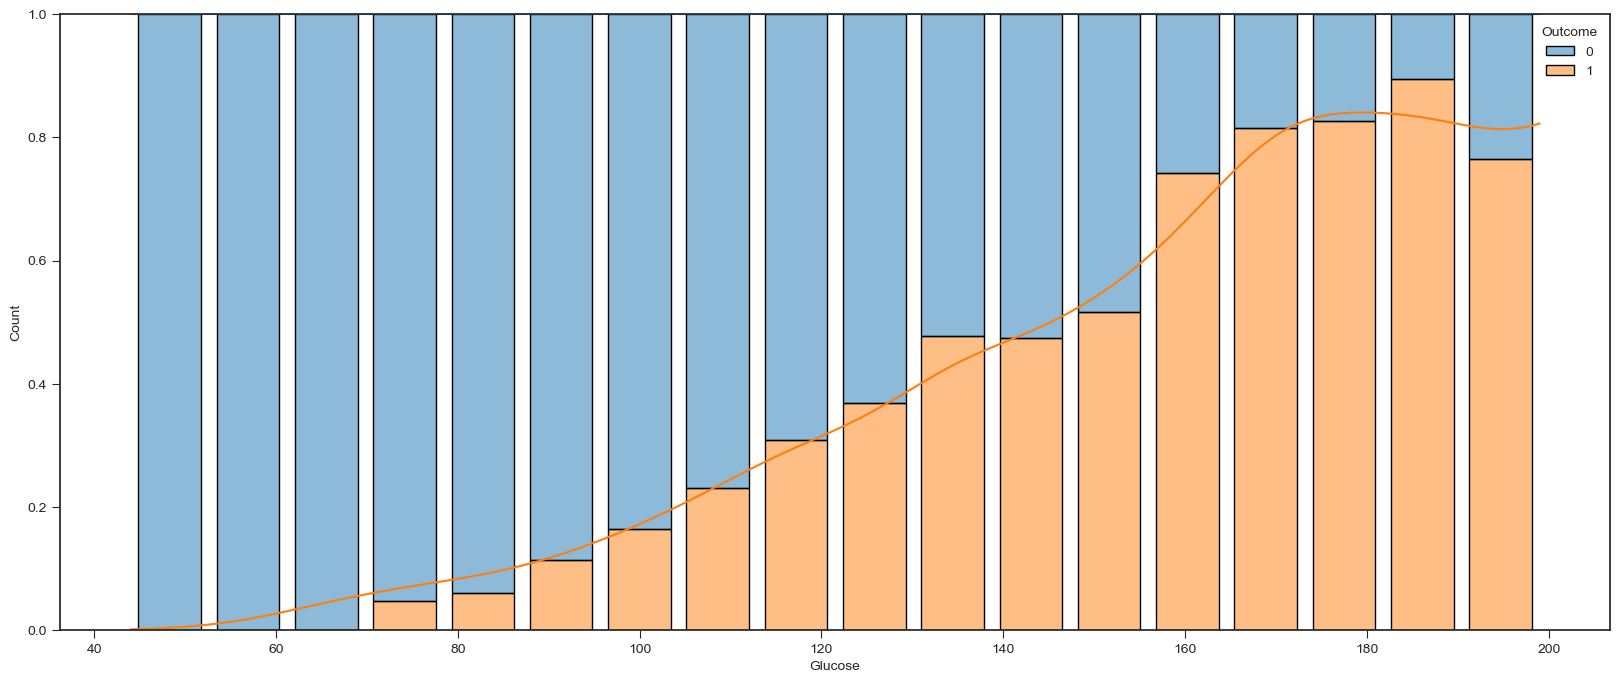

In [32]:
fig, ax = plt.subplots(figsize=(20, 8))

sns.histplot(data=df_diabetes, x="Glucose", hue="Outcome", shrink=0.8, multiple="fill", kde=True, ax=ax)
plt.show()

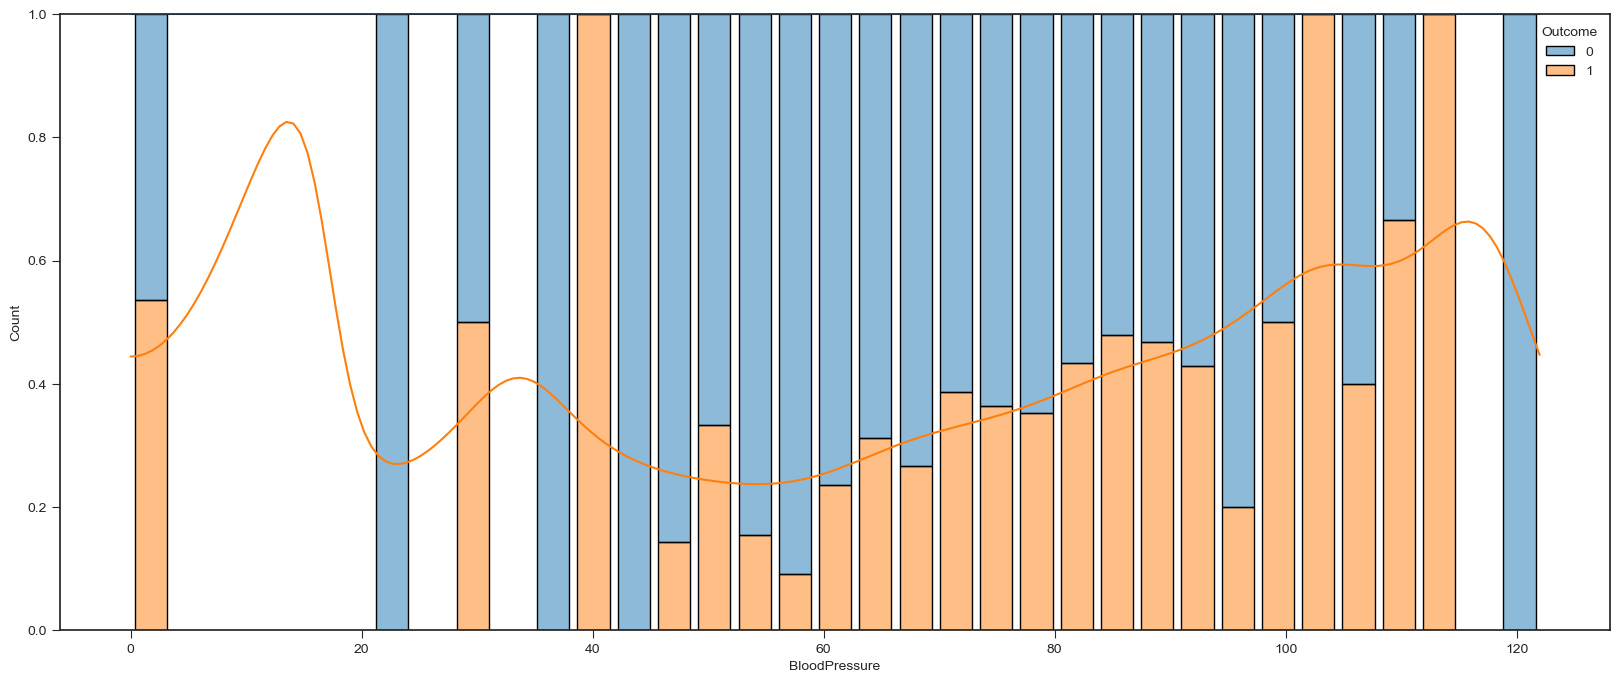

In [33]:
fig, ax = plt.subplots(figsize=(20, 8))

sns.histplot(data=df, x="BloodPressure", hue="Outcome", shrink=0.8, multiple="fill", kde=True, ax=ax)
plt.show()

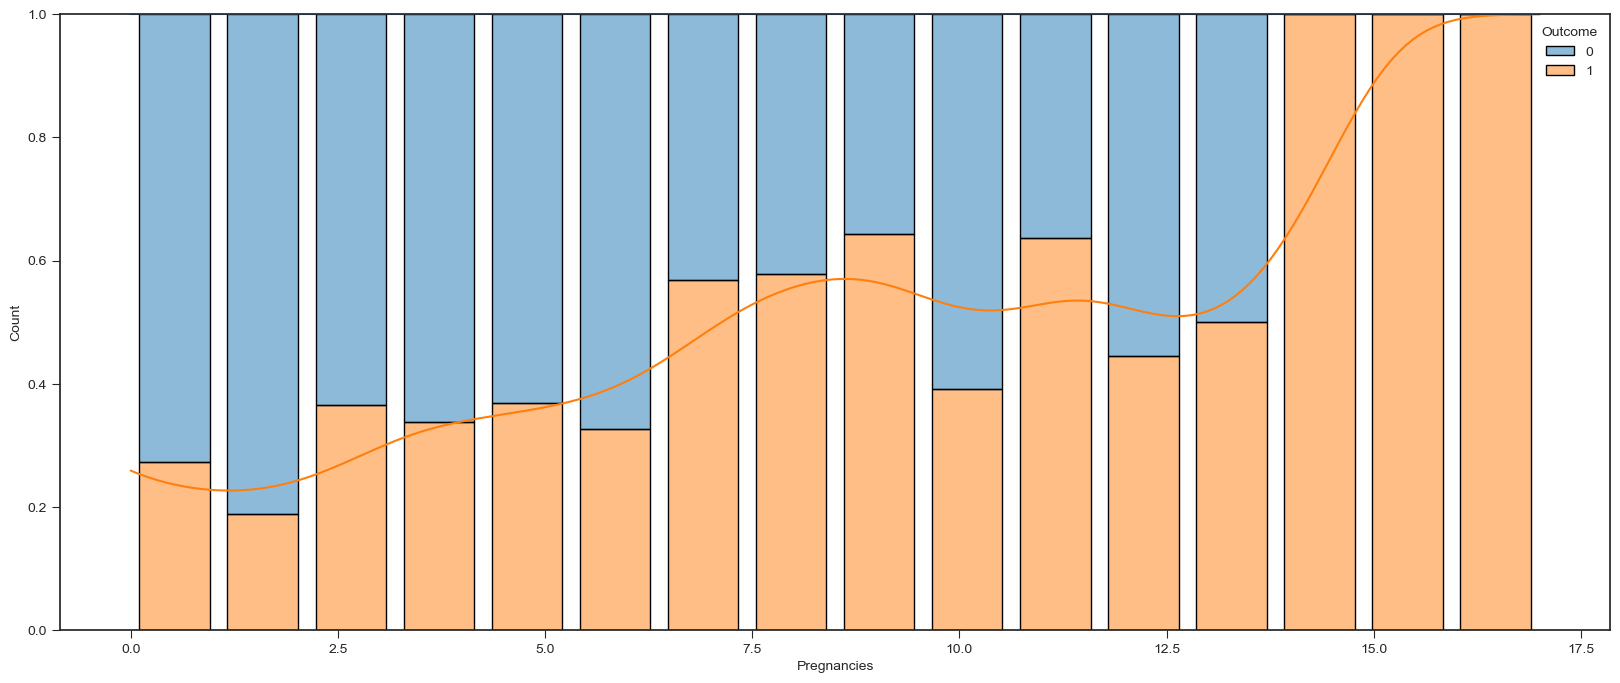

In [34]:

fig, ax = plt.subplots(figsize=(20, 8))

sns.histplot(data=df, x="Pregnancies", hue="Outcome", shrink=0.8, multiple="fill", kde=True, ax=ax)
plt.show()


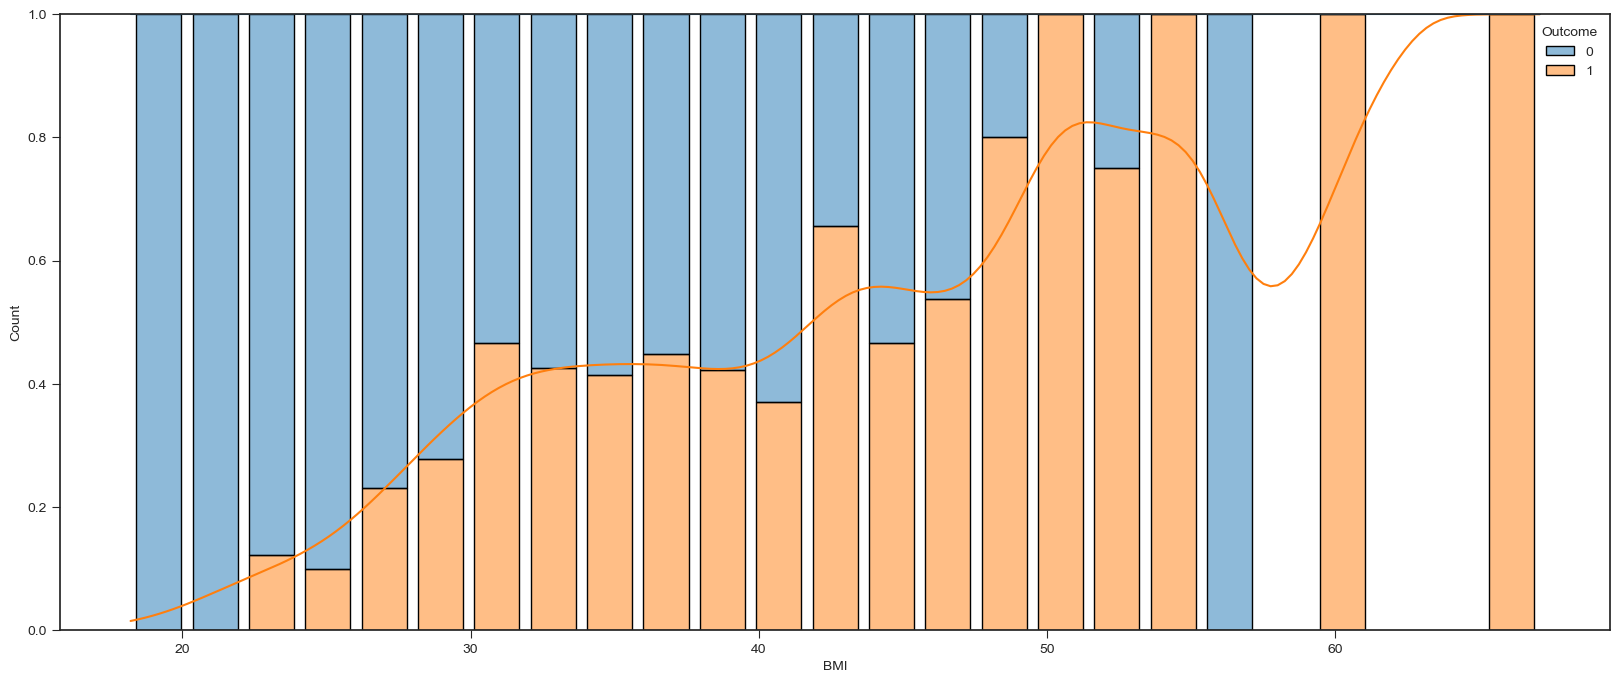

In [35]:
fig, ax = plt.subplots(figsize=(20, 8))

sns.histplot(data=df_diabetes, x="BMI", hue="Outcome", shrink=0.8, multiple="fill", kde=True, ax=ax)
plt.show()


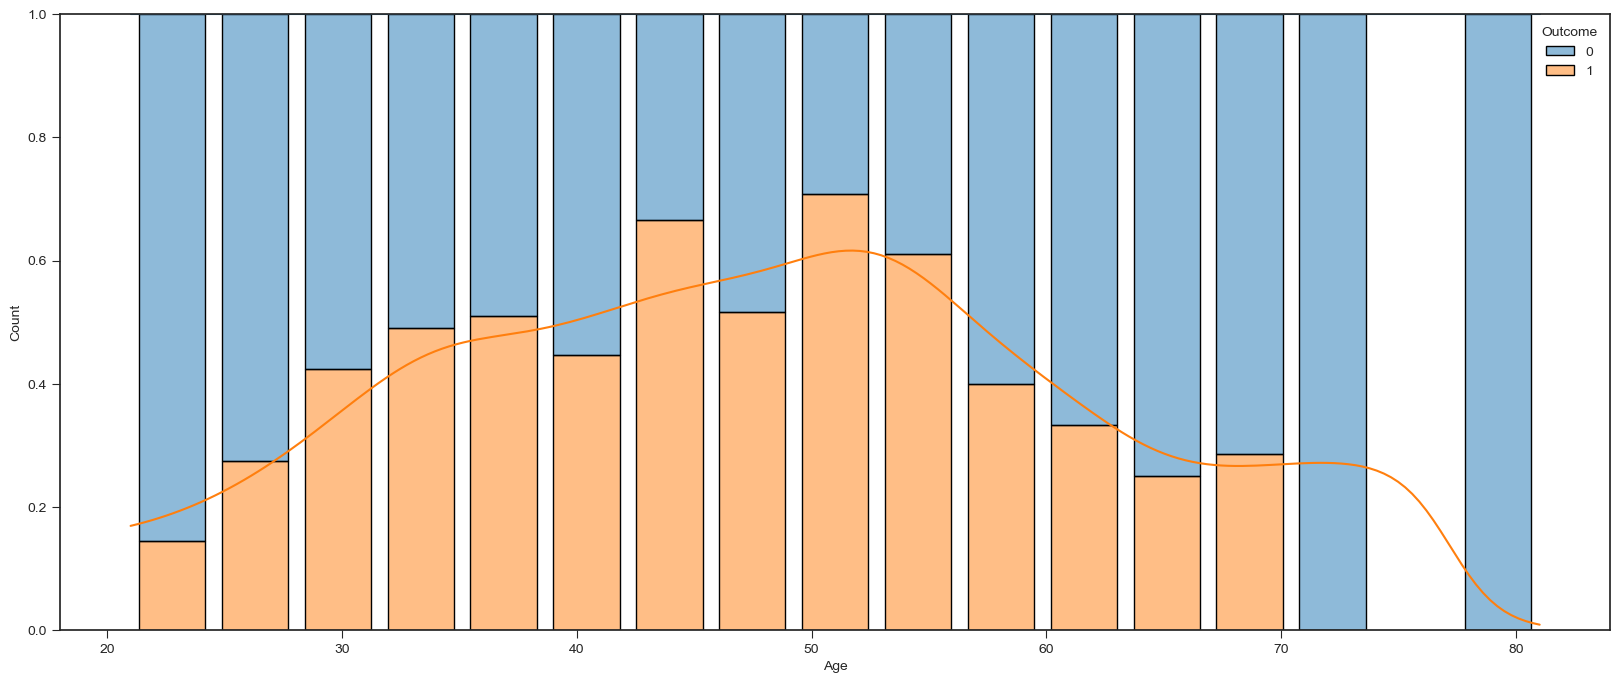

In [36]:
fig, ax = plt.subplots(figsize=(20, 8))

sns.histplot(data=df_diabetes, x="Age", hue="Outcome", shrink=0.8, multiple="fill", kde=True, ax=ax)
plt.show()

The plots above show that the chances of the outcome classification being 1 increases with Pregnanacies, BMI and Glucose levels. People in the Age limit above 40 to 60 are more prone to be diabetic.

There is some positive linear correlation with **Age**.

As the value of **Glucose** increases, the count of patients having **diabetes** increases i.e. value of Outcome as 1, increases.
Above the Glucose value of 125, there is a steady increase in the number of patients having Outcome of 1.

So, there is a significant amount of positive linear correlation between **Glucose and Outcome**.

The value of **Outcome** does not increase linearly as value of **BloodPressure**.

Positive linear correlation is evident for **BMI**.

**Model Building**:

Scaling the input column values using **standard scaler** as there is range variation in different features. It is necessary to scale them so that the Machine Learning models can perform better.



In [37]:
from sklearn.model_selection import train_test_split,cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,precision_score,recall_score,auc
from sklearn.metrics import f1_score,roc_curve,roc_auc_score

# define X and y
y = df_diabetes['Outcome']
X = df_diabetes.drop('Outcome', axis=1)


In [38]:
scaled_features = StandardScaler().fit_transform(X)

In [39]:
#Splitting the Data into 70 30 ratio
X_train, X_test, y_train, y_test = train_test_split(scaled_features, y, test_size=0.3, random_state=42,shuffle=True,stratify = y)

#Initialising the Model
lregmodel = LogisticRegression()

In [40]:
lregmodel.fit(X_train, y_train)


y_predict = lregmodel.predict(X_test)
model_score = lregmodel.score(X_test, y_test)

print(model_score)

0.7641921397379913


In [41]:
accuracy = accuracy_score(y_test, y_predict)
print("Accuracy: %.3f" % accuracy)

precision = precision_score(y_test, y_predict)
print("Precision: %.3f" % precision)

recall = recall_score(y_test, y_predict)
print("Recall: %.3f" % recall)

f1 = f1_score(y_test, y_predict)
print("F1 Score: %.3f" % f1)


Accuracy: 0.764
Precision: 0.741
Recall: 0.500
F1 Score: 0.597


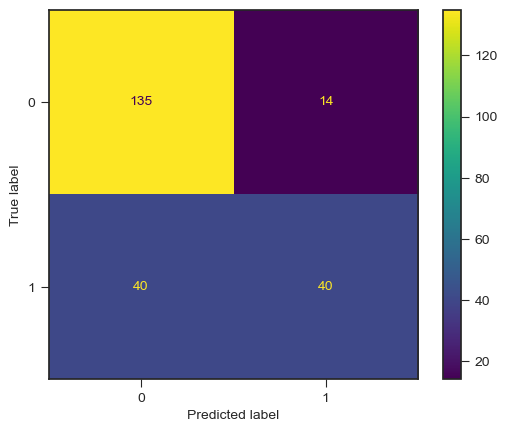

In [42]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(lregmodel, X_test, y_test);
plt.show()

In [43]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.77      0.91      0.83       149
           1       0.74      0.50      0.60        80

    accuracy                           0.76       229
   macro avg       0.76      0.70      0.72       229
weighted avg       0.76      0.76      0.75       229



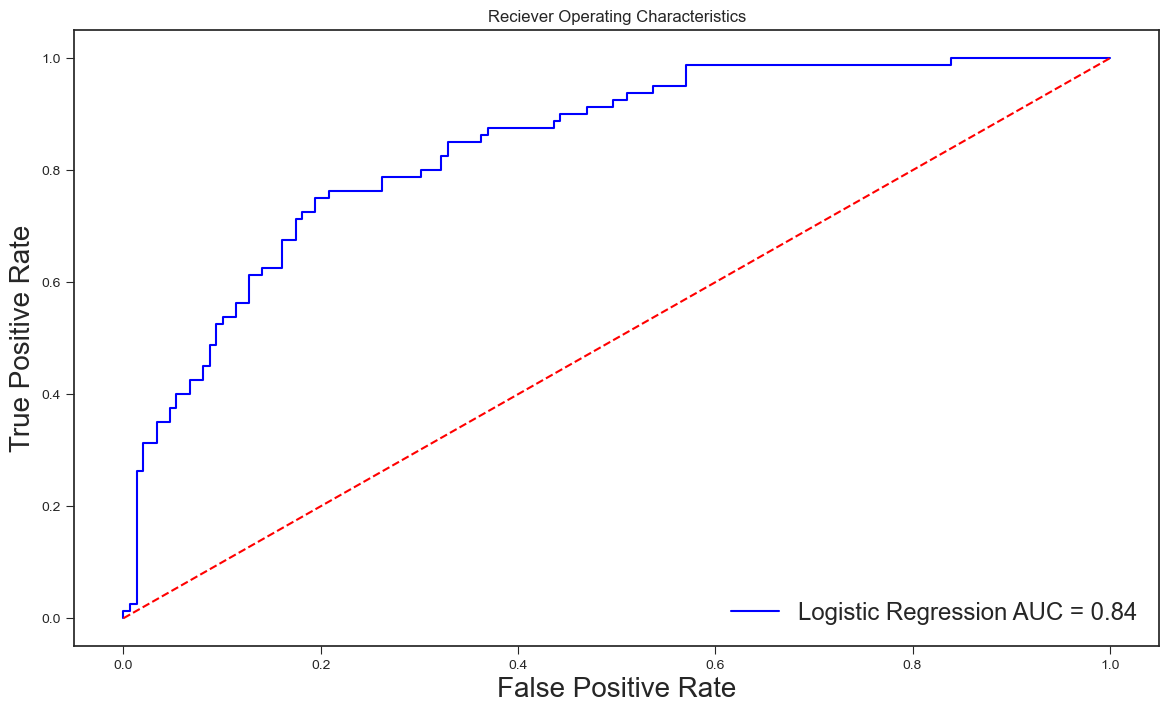

In [44]:
'''fpr, tpr, _ = roc_curve(y_test, y_predict)
auc = roc_auc_score(y_test, y_predict)

plt.figure(figsize=(12,8))
plt.plot(fpr,tpr,label="Logistic Regression (Sensitivity = %0.3f)" % auc)
plt.legend(loc=4)
plt.xlabel('False Positive Rate', size = 20)
plt.ylabel('True Positive Rate', size = 20)
plt.title("ROC", size = 25)
plt.plot([0, 1], [0, 1],'r--')
plt.legend(loc=4, fontsize='xx-large')
plt.show()'''

proba = lregmodel.predict_proba(X_test)[:,1]
fpr,tpr, threshold = roc_curve(y_test,proba)
roc_auc_ = auc(fpr,tpr)

plt.figure(figsize=(14,8))
plt.title('Reciever Operating Characteristics')
plt.plot(fpr,tpr,'b',label = 'Logistic Regression AUC = %0.2f' % roc_auc_)
plt.legend(loc='lower right')
plt.xlabel('False Positive Rate', size = 20)
plt.ylabel('True Positive Rate', size = 20)
plt.plot([0, 1], [0, 1],'r--')
plt.legend(loc=4, fontsize='xx-large')
plt.show()



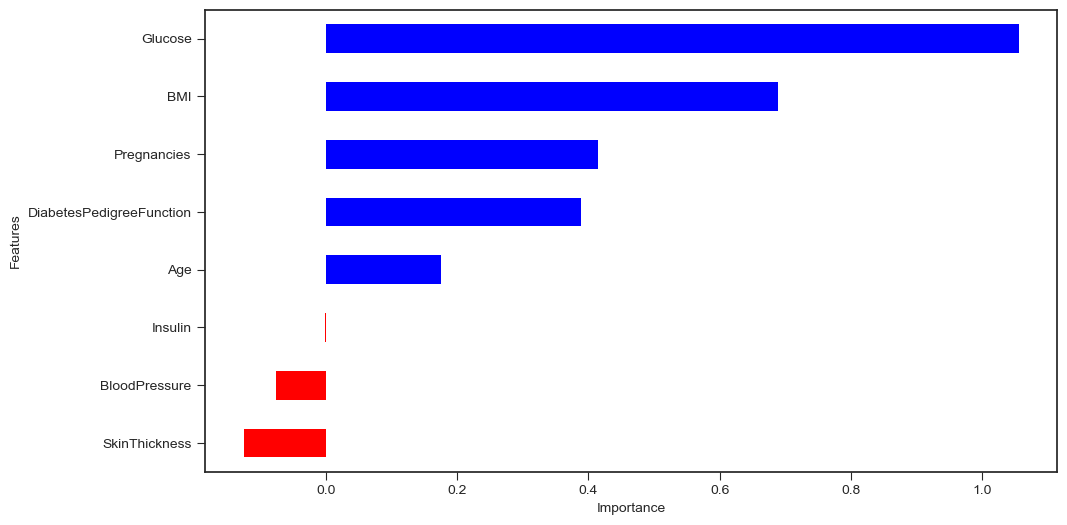

In [45]:
coeff = list(lregmodel.coef_[0])
labels = list(X.columns) # Corrected to use X.columns instead of df_diabetes.columns
features = pd.DataFrame()
features['Features'] = labels
features['importance'] = coeff
features.sort_values(by=['importance'], ascending=True, inplace=True)
features['positive'] = features['importance'] > 0
features.set_index('Features', inplace=True)
features.importance.plot(kind='barh', figsize=(11, 6),color = features.positive.map({True: 'blue', False: 'red'}))
plt.xlabel('Importance');

In the given **imbalanced dataset,** one class (class 0 - No diabetes) is significantly more prevalent than the other class (Class 1 - minority class(Diabetes)).
In a medical dataset, the number of healthy patients might outnumber the number of patients with a disease by a large margin.

Traditional logistic regression treats all classes equally during model training. Consequently, when faced with imbalanced datasets, the model tends to be biased towards the majority class. Resulting in lower sensitivity (true positive rate) for the minority class, leading to poor performance in predicting rare events.

As seen in the above traditional logistic regression - classification report,the recall value is less compared to that of the Majority class.


**Weighted Logistic Regression:**

Weighted logistic regression addresses this issue by assigning different weights to each class based on their prevalence in the dataset. The weights are incorporated into the loss function during model training.
Higher weights are assigned to the minority class and lower weights to the majority class, the model is encouraged to pay more attention to the minority class, thereby reducing the bias towards the majority class.

In healthcare, finance, fraud detection, and anomaly detection, it is necessary that **recall value** be **higher** as real/true positive cases need to be predicted correctly by the model.Correctly identifying  these rare events or minority classes is very crucial.

The weighted logistic regression algorithm adjusts the model parameters to minimize the weighted sum of errors, where errors from the minority class are assigned higher weights. Thus the model focuses on correctly classifying instances from the minority class and correctly predicting the rare events.


In [46]:
# Fit a weighted logistic regression model
weights = {0: 1, 1: 2}  # Weight 2 for class 1 (minority class)
lrwt_model = LogisticRegression(random_state=42, class_weight=weights,max_iter=2000)
lrwt_model.fit(X_train, y_train)

# Make predictions with the weighted model
y_pred_weighted_lr = lrwt_model.predict(X_test)

# Evaluate the weighted model
print("Weighted Logistic Regression:")
print(classification_report(y_test, y_pred_weighted_lr))

print("Traditional Logistic Regression without weight balance:")
print(classification_report(y_test, y_predict))

Weighted Logistic Regression:
              precision    recall  f1-score   support

           0       0.85      0.81      0.83       149
           1       0.67      0.72      0.70        80

    accuracy                           0.78       229
   macro avg       0.76      0.77      0.76       229
weighted avg       0.79      0.78      0.78       229

Traditional Logistic Regression without weight balance:
              precision    recall  f1-score   support

           0       0.77      0.91      0.83       149
           1       0.74      0.50      0.60        80

    accuracy                           0.76       229
   macro avg       0.76      0.70      0.72       229
weighted avg       0.76      0.76      0.75       229



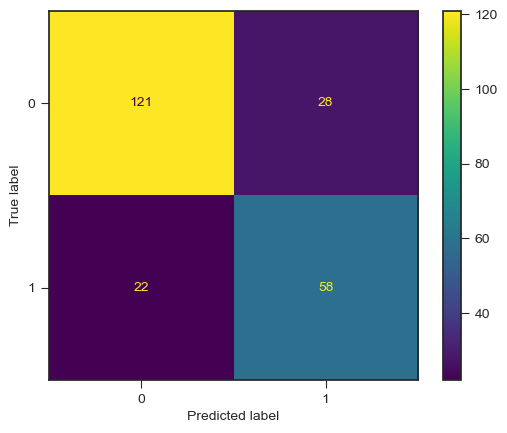

In [47]:
ConfusionMatrixDisplay.from_estimator(lrwt_model, X_test, y_test);
plt.show()

Text(0.5, 0, 'False positive rate')

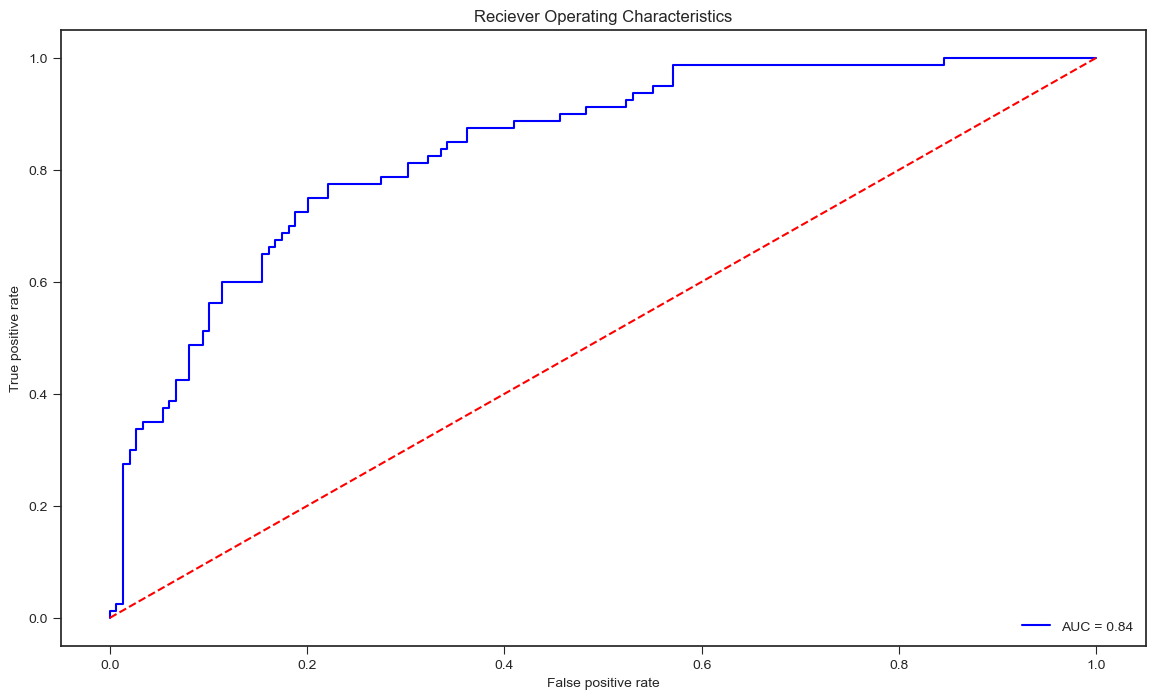

In [48]:

proba = lrwt_model.predict_proba(X_test)[:,1]
frp,trp, threshold = roc_curve(y_test,proba)
roc_auc_ = auc(frp,trp)

plt.figure(figsize=(14,8))
plt.title('Reciever Operating Characteristics')
plt.plot(frp,trp,'b',label = 'AUC = %0.2f' %roc_auc_)
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],'r--')
plt.ylabel('True positive rate')
plt.xlabel('False positive rate')


The ROC AUC value is calculated based on the size of the area under the ROC curve and takes a value between 0 and 1. If a ROC AUC is 1, the model has made all of its predictions correctly. If a ROC AUC is 0, the model has made all of its predictions incorrectly. If a ROC AUC was 0.5, the accuracy of the model predictions had a random distribution. The ROC AUC value is a useful metric for measuring the performance of a classification model.

In [49]:
coeff = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lrwt_model.coef_[0]
})
coeff

,Feature,Coefficient
0,Pregnancies,0.428766
1,Glucose,1.094794
2,BloodPressure,-0.060743
3,SkinThickness,-0.164950
4,Insulin,-0.023165
5,BMI,0.742919
6,DiabetesPedigreeFunction,0.423703
7,Age,0.199214


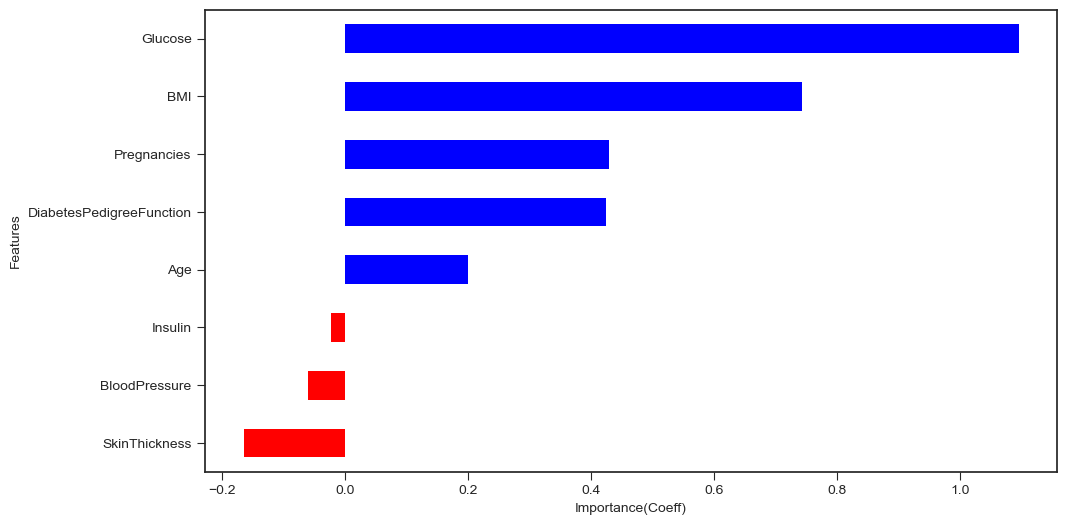

In [50]:
coeff = list(lrwt_model.coef_[0])
labels = list(X.columns) # Corrected to use X.columns instead of df_diabetes.columns
features = pd.DataFrame()
features['Features'] = labels
features['importance'] = coeff
features.sort_values(by=['importance'], ascending=True, inplace=True)
features['positive'] = features['importance'] > 0
features.set_index('Features', inplace=True)
features.importance.plot(kind='barh', figsize=(11, 6),color = features.positive.map({True: 'blue', False: 'red'}))
plt.xlabel('Importance(Coeff)');

Features like Glucose, BMI, Diabetes Pedigree Function, Pregnancies and Age respectively have stronger influence on the outcome.

**Cross Validation - K Fold**

In [51]:
#Model Validation: 5-Fold Cross Validation
from  sklearn.model_selection import GridSearchCV,StratifiedKFold
import numpy as np

lrv_model = LogisticRegression(solver='liblinear',random_state=42, class_weight=weights,max_iter=2000)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) #10-fold stratified cross-validation

acc_stratified = [] #store accuracy scores

for train_index, test_index in skf.split(X, y): #splits dataset into stratified train-test indices
	X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
	y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]
	lrv_model.fit(X_train_fold, y_train_fold)
	acc_stratified.append(lrv_model.score(X_test_fold, y_test_fold))
	roc_auc= roc_auc_score(y_test_fold,lrv_model.predict(X_test_fold))
	print('ROC AUC :',roc_auc)


print(' Possible accuracy:', acc_stratified)
print('\nMaximum Accuracy That can be obtained from this model is:',
	max(acc_stratified)*100, '%')
print('\nMinimum Accuracy:',
	min(acc_stratified)*100, '%')
print('\nOverall Accuracy:',
	np.mean(acc_stratified)*100, '%')
print('\nStandard Deviation is:', np.std(acc_stratified))

ROC AUC : 0.7500000000000001
ROC AUC : 0.7479213907785336
ROC AUC : 0.7982656756241662
ROC AUC : 0.7403278063655423
ROC AUC : 0.7517629121402707
 Possible accuracy: [0.7581699346405228, 0.75, 0.7828947368421053, 0.7302631578947368, 0.756578947368421]

Maximum Accuracy That can be obtained from this model is: 78.28947368421053 %

Minimum Accuracy: 73.02631578947368 %

Overall Accuracy: 75.55813553491572 %

Standard Deviation is: 0.016887151275679923


In [52]:
print('Confusion matrix\n',confusion_matrix(y_test_fold,lrv_model.predict(X_test_fold)))


Confusion matrix
 [[76 23]
 [14 39]]


In [53]:
print('Classification report\n',classification_report(y_test_fold,lrv_model.predict(X_test_fold)))


Classification report
               precision    recall  f1-score   support

           0       0.84      0.77      0.80        99
           1       0.63      0.74      0.68        53

    accuracy                           0.76       152
   macro avg       0.74      0.75      0.74       152
weighted avg       0.77      0.76      0.76       152



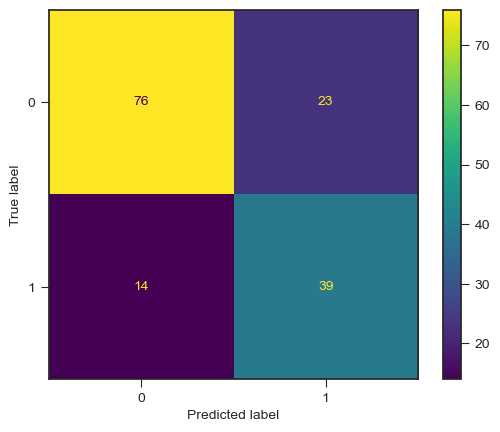

In [54]:
ConfusionMatrixDisplay.from_estimator(lrv_model, X_test_fold, y_test_fold);
plt.show()

Using Stratified K-Fold Cross Validation for imbalanced classification data set ensures that the learning model is evaluated fairly and consistently leading to more accurate predictions and better real-world performance.

Text(0.5, 0, 'False positive rate')

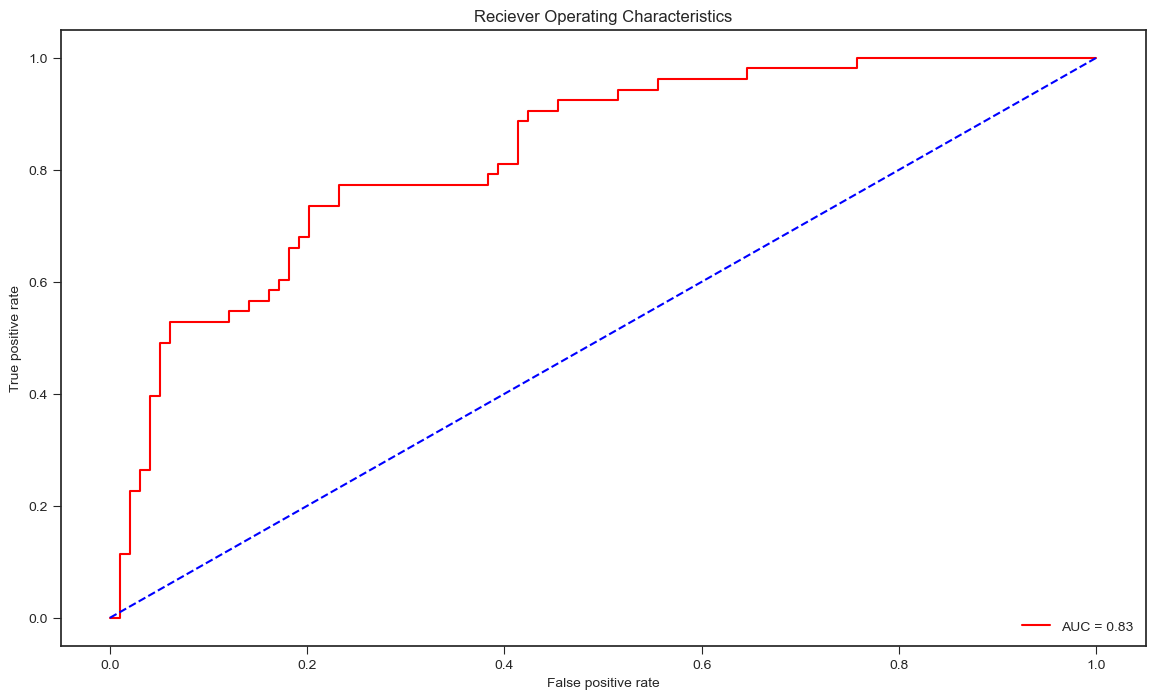

In [55]:
from sklearn.metrics import auc

proba = lrv_model.predict_proba(X_test_fold)[:,1]
frp,trp, threshold = roc_curve(y_test_fold,proba)
roc_auc_ = auc(frp,trp)

plt.figure(figsize=(14,8))
plt.title('Reciever Operating Characteristics')
plt.plot(frp,trp,'r',label = 'AUC = %0.2f' % roc_auc_)
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],'b--')
plt.ylabel('True positive rate')
plt.xlabel('False positive rate')

**Predicting** for new input values:

In [56]:
X.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')

In [57]:
new_observation = pd.DataFrame([[8, 128, 80, 35, 12, 33.6, 0.627, 30]], columns=X.columns)
prediction = lrv_model.predict(new_observation)
print(prediction)

[1]



Algorithms that use gradient descent to minimize the loss function, such as Linear regression, Logistic regression, and neural networks, are sensitive to difference in feature scales, so scaling is necessary.
Hence, we have used the **standard scaling** for scaling the independent parameter values.

**Evaluation Metrics:**
The recall value for minority class(1 - Diabetic), improved with the weighted logistic regression. The given dataset is imbalanced with only 35% data for (Classification 1 - diabetic true). **The recall value should be high in healthcare, finance, fraud detection, and anomaly detection.**

In our case, it is crucial for the model to classify a diabetic patient as positive.

**Receiver Operating Characteristic (ROC)** A Receiver Operator Characteristic (ROC) curve is a graphical plot used to show the diagnostic ability of binary classifiers. It was first used in signal detection theory but is now used in many other areas such as medicine, radiology, natural hazards and machine learning. It helps identify the optimal trade-off between sensitivity and specificity, with an Area Under the Curve (AUC) score of 1.0 indicating a perfect model and 0.5 representing random guessing.

The plotted coefficients, show the importance of the independent features.

A ROC curve is constructed by plotting the true positive rate (TPR) against the false positive rate (FPR). The true positive rate is the proportion of observations that were correctly predicted to be positive out of all positive observations (TP/(TP + FN)). Similarly, the false positive rate is the proportion of observations that are incorrectly predicted to be positive out of all negative observations (FP/(TN + FP)). In this scenario, the true positive rate is the rate in which people are correctly identified to test positive for the diabetic.

The ROC curve shows the trade-off between sensitivity (or TPR) and specificity (1 - FPR). Classifiers that give curves closer to the top-left corner indicate a better performance. A random classifier is expected to give points lying along the diagonal (FPR = TPR). The closer the curve comes to the 45-degree diagonal of the ROC space, the less accurate is the test. A curve closer to the top-left corner indicates a more accurate classifier.



**Conclusion**
 Logistic Regression has been shown to be one of the efficient algorithms in building prediction models.
 The accuracy of the model does not only depend on the algorithm chosen, but also on other factors.
 Data-preprocessing is one of the important factor.
 Removing redundant and null values is essential in improving performance.
 The normalization of values, when the features differ by large scale, also plays an important role.
 Cross-validation also holds an essential role to boost accuracy.

**Interview Questions**:
1. What is the difference between precision and recall?

Precision and recall are two important accuracy measures in a machine learning model.

**Precision** is the ratio of a models prediction/classification of all positive classifications as positive.

**Recall** (also known as the true positive rate) is the ratio of all actual positives predicted/classified correctly as positives.

Precision and recall help in classification problems where data falls into one class more often than another.

**Precision** = true positives / true positives + false positives = TP / TP + FP

A hypothetical perfect model would have zero false positives and therefore a precision of 1.0.

In an imbalanced dataset where the number of actual positives is very, very low, precision is less meaningful and less useful as a metric.

Only precision being considered, we will miss out on classifying false negatives in your model as precision only evaluates how a model performs at accurately classifying the true positives. For example: If we optimize the  diabetic detection model only for precision, we will miss out on the positive outcomes being classified as falsely as negative and that becomes a problem in the field of medical research/diagnosis or other crucial fields of finance or fraud detection.


**Recall**, also known as the TP rate, evaluates  a machine learning model classification of all true positives in the data set. This tells us how many positives evaluated are actually true positives compared to actual positives in the data set. The formula to calculate recall is as follows:

Recall = true positives / true positives + false negatives = TP / TP + FN

A false negative is a positive classification that has been misclassified as a negative by the model.
In our example, recall is the total number of patients correctly classified as diabetic by the model.  
A hypothetical perfect model would have zero false negatives and therefore a recall (TPR) of 1.0, which is to say, a 100% detection rate.

Precision improves as false positives decrease, while recall improves when false negatives decrease.

2. What is cross-validation, and why is it important in binary classification?

Cross-validation is a technique used in evaluating the performance of a machine learning model performs on unseen data by preventing overfitting.

Basically involves,
- partitioning the dataset into multiple subsets.
- Training the model on some parts and testing it on the remaining part.
- Repeating this resampling process multiple times by choosing different parts of the dataset.
- Averaging the results from each validation step to get the final performance.

Cross-validation is a procedure that is used to avoid overfitting and estimate the skill of the model on new data.

4 types of cross validation techniques include:
1) K-Fold Cross-Validation
2) Stratified K Fold Cross-Validation
3) Leave-P-Out Cross-Validation
4) Holdout Method

In a binary classification problem, there can only be two possibilities: a data point belongs to class A or B. So, with cross validation we can be sure to arrange the data such that in every fold, each class consists of about half the instances in that fold.

For example, let us get a fold with the majority belonging to one class(say positive) and only a few as a negative class. This will undoubtedly ruin our training, and to avoid this, we make stratified folds using stratification.
Stratification is the process of rearranging the data to ensure that each fold represents the whole.

By using cross-validation, we are not just making sure that our model works well with our current data, but helps in ensuring that it can generalize to new data. Cross-validation provides a more accurate estimate of out-of-sample error, and is a more efficient use of data as every observation is used for both training and validation. This is particularly useful in scenarios where every bit of data is invaluable.



In [58]:
import streamlit as st
import pickle
import numpy as np

In [59]:
# Storing the ML Model
with open('log_model.pkl', 'wb') as f:
    pickle.dump(lrv_model, f)

**Streamlit App - Deployment**

In [60]:
!pip install streamlit

In [61]:
# Step 1: Gathering the Inputs

In [62]:
# Feature selection on sidebar
import warnings 
warnings.filterwarnings("ignore") 

def get_user_input():
    Pregnancies = st.number_input("Pregnancies", min_value=0)
    Glucose = st.number_input("Glucose")
    BloodPressure = st.number_input("Blood Pressure")
    SkinThickness = st.number_input("Skin Thickness")
    Insulin = st.number_input("Insulin")
    BMI = st.number_input("BMI")
    DiabetesPedigreeFunction = st.number_input("Diabetes Pedigree Function")
    Age = st.number_input("Age")
    
    user_data = {
        'Pregnancies': 1,
        'Glucose': 100,
        'BloodPressure': 100,
        'SkinThickness': 18,
        'Insulin': 18,
        'BMI': 33,
        'DiabetesPedigreeFunction': 0.71,
        'Age': 43,
    }
    return user_data

user_data = get_user_input()
user_data

2026-02-12 09:32:52.452 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-12 09:32:52.454 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-12 09:32:52.456 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-12 09:32:52.458 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-12 09:32:52.459 WARNING streamlit.runtime.state.session_state_proxy: Session state does not function when running a script without `streamlit run`
2026-02-12 09:32:52.461 WARNING streamlit.runtime.scriptrunner_utils.script_run_c

{'Pregnancies': 1,
 'Glucose': 100,
 'BloodPressure': 100,
 'SkinThickness': 18,
 'Insulin': 18,
 'BMI': 33,
 'DiabetesPedigreeFunction': 0.71,
 'Age': 43}

In [63]:
#Step 2: Transforming the Inputs
X.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')

In [64]:
def prepare_input(data, feature_list):
    input_data = {feature: data.get(feature, 0) for feature in feature_list}
    return np.array([list(input_data.values())])

# Feature list (same order as used during model training)
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
            'BMI', 'DiabetesPedigreeFunction', 'Age']

# array of inputs
input_array = prepare_input(user_data, features)
input_array

array([[  1.  , 100.  , 100.  ,  18.  ,  18.  ,  33.  ,   0.71,  43.  ]])

In [65]:
#Step 3: Making the Prediction

In [66]:
# prediction
prediction = lrv_model.predict(input_array)
prediction

array([0])

In [67]:
#Creating the app

In [68]:
import streamlit as st
import numpy as np
import pandas as pd
import pickle
import plotly.express as px
from PIL import Image


In [69]:
# Page configuration
st.set_page_config(layout="wide")

# Load your pre-trained model
with open('log_model.pkl', 'rb') as f:
    lrv_model2 = pickle.load(f)

def get_user_input():
    Pregnancies = st.number_input("Pregnancies", min_value=0)
    Glucose = st.number_input("Glucose")
    BloodPressure = st.number_input("Blood Pressure")
    SkinThickness = st.number_input("Skin Thickness")
    Insulin = st.number_input("Insulin")
    BMI = st.number_input("BMI")
    DiabetesPedigreeFunction = st.number_input("Diabetes Pedigree Function")
    Age = st.number_input("Age")

    '''user_data = {
        'Pregnancies': 1,
        'Glucose': 100,
        'BloodPressure': 100,
        'SkinThickness': 18,
        'Insulin': 18,
        'BMI': 33,
        'DiabetesPedigreeFunction': 0.71,
        'Age': 43,
    }'''
    return user_data

st.markdown("<h1 style='text-align: center;'>Diabetes Prediction App</h1>", unsafe_allow_html=True)

user_data = get_user_input()

def prepare_input(data, feature_list):
    input_data = {feature: data.get(feature, 0) for feature in feature_list}
    return np.array([list(input_data.values())])

# Feature list (same order as used during model training)
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
            'BMI', 'DiabetesPedigreeFunction', 'Age']
# Predict button
if st.button("Predict"):
    input_array = prepare_input(user_data, features)
    prediction = lrv_model2.predict(input_array)
    st.subheader("Diabetes")
    #st.write(f"${prediction[0]:,.2f}")

    if prediction[0] == 1:
        st.error(f"Diabetes (Probability: {probability:.2f})")
    else:
        st.success(f"No Diabetes (Probability: {probability:.2f})")
        

2026-02-12 09:32:53.608 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-12 09:32:53.615 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-12 09:32:53.616 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-12 09:32:53.617 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-12 09:32:53.620 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-12 09:32:53.622 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-12 09:32:53.623 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-12 09:32:53.626 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar